In [1]:
import pandas as pd
import numpy as np
from utils import Utils
import matplotlib.pyplot as plt
import seaborn as sns
from simulation import Simluation, run_simulation, load_test_data

In [2]:
# Step 1 : Massive data, I need to club them together
DF = Utils.load_data()
# Utils.validate_data(DF)

In [3]:
# For analysis, let's use low as open

DF.loc["2021-05-05", ("Asset_77", "Low")] = DF.loc["2021-05-05", ("Asset_77", "Open")]
Utils.validate_data(DF)

Data is valid

In [4]:
# Let's check for corporate actions as mentioned here:
# https://www.ml4trading.io/docs/data/tutorials/01_understanding_ohlcv/

candidates = Utils.corporate_action_candidates(DF)
candidates.head()

# Three possible data points, but 1. OLHCV is not enough 2. It's only 3 data point. 

Metric,Open,Close,Volume,price_ratio,overnight_return,volume_multiple,asset,volume_confirmation
Date,,,,,,,,
2025-10-06,135.506819,121.899295,342288124,1.375175,0.375175,5.948399,Asset_36,True
2016-07-05,75.848048,78.767544,20633105,1.552429,0.552429,5.134882,Asset_39,True
2020-03-09,31.605241,31.092543,11240269,0.691139,-0.308861,5.555273,Asset_94,True


In [5]:
tr_, te_ = Utils.split_train_test(DF, test_size=0.2)
tr_.shape, te_.shape
Utils.validate_split(tr_, te_, DF)

split is valid

In [6]:
# I need to get log returns. 
# Let's do the feature engineering and test for stationarity later

# Since the dataset is large, Let's select first N assets.

N = 25
assets = tr_.columns.get_level_values(0).unique()[:N]
df = tr_.loc[:, assets]


In [7]:
print(df)

Asset          Asset_1                                                 \
Metric            Open        High         Low       Close     Volume   
Date                                                                    
2016-01-25   29.178415   29.181290   28.514486   28.580592  249449990   
2016-01-26   28.721415   28.994458   28.186822   28.738659  361581962   
2016-01-27   27.603374   27.772948   26.827351   26.850345  642328247   
2016-01-28   26.956690   27.166502   26.554308   27.042913  268157355   
2016-01-29   27.244108   27.977016   27.117645   27.977016  310239413   
...                ...         ...         ...         ...        ...   
2024-01-10  232.800675  235.389438  232.257652  235.124257   56340385   
2024-01-11  235.566195  236.210245  231.878767  234.366521   59152414   
2024-01-12  234.960074  235.818800  233.861427  234.783280   48736771   
2024-01-16  230.035029  232.686936  228.481748  231.891374   78988443   
2024-01-17  228.911170  231.007434  227.686234  230

In [8]:
# Features to look at: 
# Returns, Volatility, Residual Return

df = Utils.with_cumulative_return(df)

# get log return 
df = Utils.with_log_return(df)

# get volatility 
# I'm using EWMA Volatility 
df = Utils.with_volatility(df)

# get residual return (log return minus equal-weight market)
df = Utils.with_residual_return(df)
df.head()

Asset         Asset_1                                                     \
Metric          Close Cumulative Return       High Log Return        Low   
Date                                                                       
2016-01-25  28.580592          1.000000  29.181290        NaN  28.514486   
2016-01-26  28.738659          1.005531  28.994458   0.005515  28.186822   
2016-01-27  26.850345          0.939461  27.772948  -0.067965  26.827351   
2016-01-28  27.042913          0.946198  27.166502   0.007146  26.554308   
2016-01-29  27.977016          0.978882  27.977016   0.033958  27.117645   

Asset                                                         Asset_10  ...  \
Metric           Open Residual Return Volatility     Volume      Close  ...   
Date                                                                    ...   
2016-01-25  29.178415             NaN        NaN  249449990  42.825875  ...   
2016-01-26  28.721415       -0.003175        NaN  361581962  42.909438  ...   
2016-01-27  27.603374       -0.053738   0.005531  642328247  42.330410  ...   
2016-01-28  26.956690       -0.004237   0.016964  268157355  41.387201  ...   
2016-01-29  27.244108        0.008891   0.016541  310239413  44.467507  ...   

Asset       Asset_8    Asset_9                                          \
Metric       Volume      Close Cumulative Return       High Log Return   
Date                                                                     
2016-01-25  6633110  59.433653          1.000000  60.517437        NaN   
2016-01-26  4666986  59.615496          1.003060  59.768244   0.003055   
2016-01-27  4979853  59.470021          1.000612  60.553806  -0.002443   
2016-01-28  4437609  55.869516          0.940032  60.000995  -0.062453   
2016-01-29  8240138  57.535198          0.968058  57.767957   0.029378   

Asset                                                                  
Metric            Low       Open Residual Return Volatility    Volume  
Date                                                                   
2016-01-25  59.368192  60.008278             NaN        NaN   2767392  
2016-01-26  58.851758  59.462749       -0.005635        NaN   4817710  
2016-01-27  58.888121  59.360914        0.011783   0.003060   4563864  
2016-01-28  55.673128  59.550027       -0.073837   0.003026  10646494  
2016-01-29  56.175014  56.269571        0.004311   0.015117   7402523  

[5 rows x 225 columns]

In [9]:
print(type(df.columns))
print(df.columns[:10])


<class 'pandas.MultiIndex'>
MultiIndex([( 'Asset_1',             'Close'),
            ( 'Asset_1', 'Cumulative Return'),
            ( 'Asset_1',              'High'),
            ( 'Asset_1',        'Log Return'),
            ( 'Asset_1',               'Low'),
            ( 'Asset_1',              'Open'),
            ( 'Asset_1',   'Residual Return'),
            ( 'Asset_1',        'Volatility'),
            ( 'Asset_1',            'Volume'),
            ('Asset_10',             'Close')],
           names=['Asset', 'Metric'])


In [10]:
## Check for correlation between assets


# import pandas as pd

# # 1. Create a sample DataFrame
# data = {
#     'Jan': [10, 20, 15, 30],
#     'Feb': [15, 25, 10, 35],
#     'Mar': [12, 22, 18, 40],
#     'Apr': [18, 28, 12, 45]
# }
# # Rows represent entities (e.g., Company A, Company B)
# df = pd.DataFrame(data, index=['Company_A', 'Company_B', 'Company_C', 'Company_D'])

# print("Original DataFrame:")
# print(df)
# print("\n" + "="*40 + "\n")

# # 2. Extract the two rows as Series
# row1 = df.loc['Company_A']
# row2 = df.loc['Company_B']

# # 3. Calculate correlation using pandas (.corr calculates column-wise by default, but individual rows are Series)
# correlation_direct = row1.corr(row2)
# print(f"Correlation between Company_A and Company_B: {correlation_direct:.4f}")

# # Alternative: Transpose the DataFrame to get a full row-by-row correlation matrix
# row_correlation_matrix = df.T.corr()
# print("\nFull Row Correlation Matrix:")
# print(row_correlation_matrix)

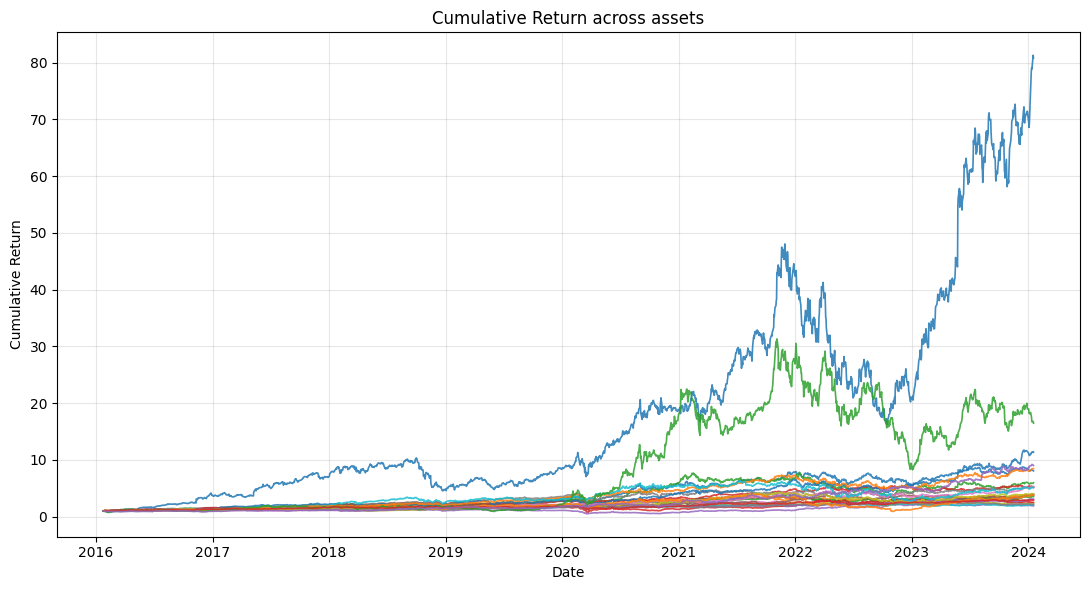

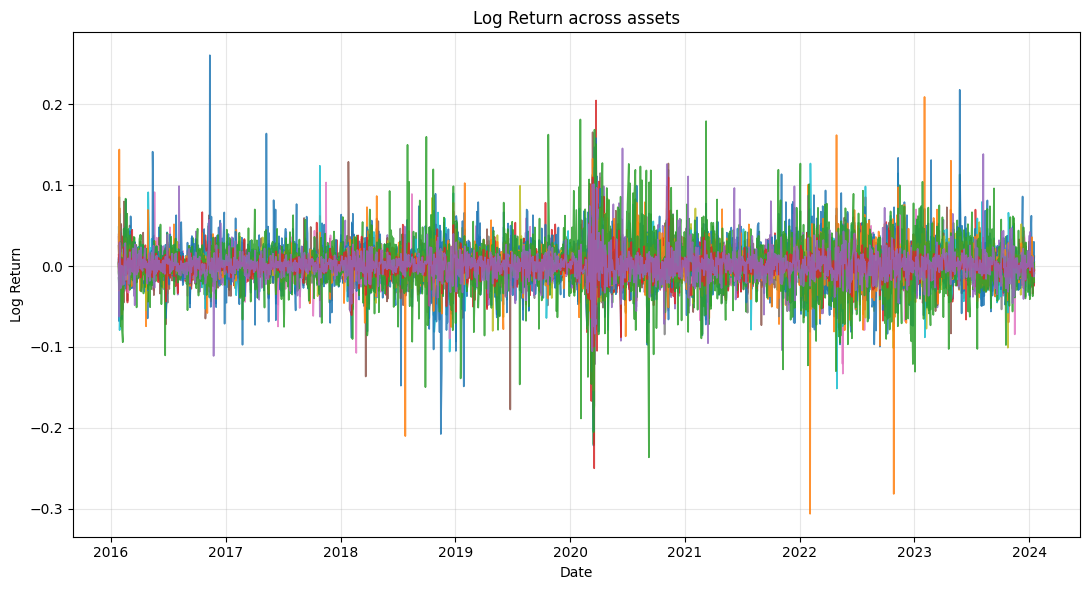

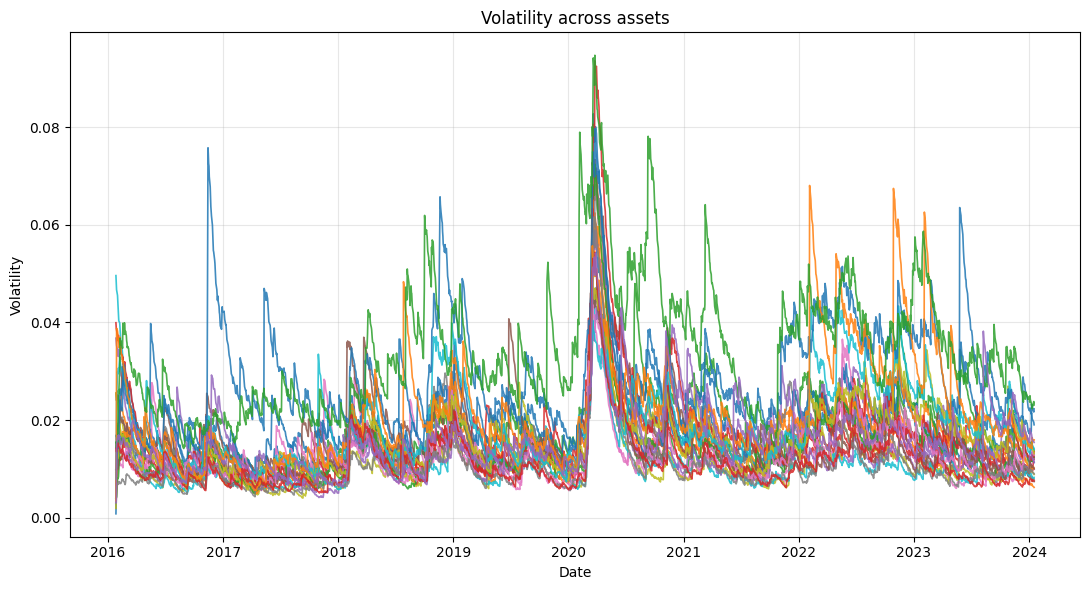

(<Figure size 1100x600 with 1 Axes>,
 <Axes: title={'center': 'Volatility across assets'}, xlabel='Date', ylabel='Volatility'>)

In [11]:
Utils.plot_metric(df, "Cumulative Return")
Utils.plot_metric(df, "Log Return")
Utils.plot_metric(df, "Volatility")

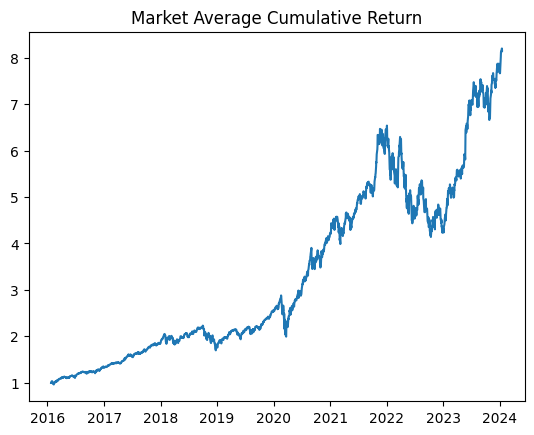

In [12]:
# Let's get market average return
avg_cumulative_ret = df.xs("Cumulative Return", axis=1, level="Metric").mean(axis=1)
plt.plot(avg_cumulative_ret)
plt.title("Market Average Cumulative Return")
plt.show()


# This can be used to feature the market behaviour over time in model.


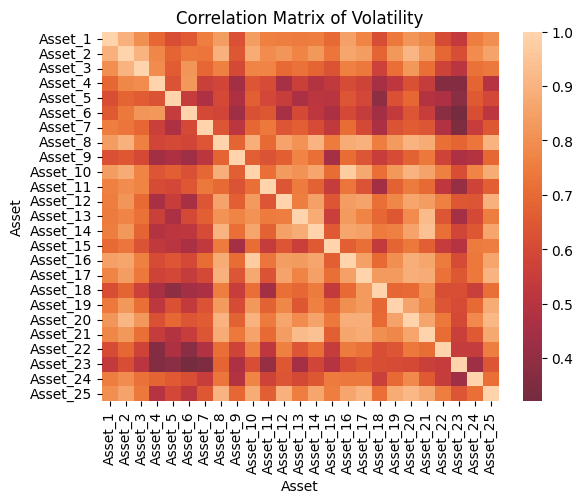

In [13]:
# Let's get correlation matrix for the return and volatility
vol = df.xs("Volatility", axis=1, level="Metric")
vol = vol[2:]
vol = vol[sorted(vol.columns, key=lambda a: int(str(a).split("_")[1]))]
vol_corr= vol.corr()
sns.heatmap(vol_corr, annot=False, center = 0)
plt.title("Correlation Matrix of Volatility")
plt.show()

In [14]:
vol_corr.head()

Asset,Asset_1,Asset_2,Asset_3,Asset_4,Asset_5,Asset_6,Asset_7,Asset_8,Asset_9,Asset_10,...,Asset_16,Asset_17,Asset_18,Asset_19,Asset_20,Asset_21,Asset_22,Asset_23,Asset_24,Asset_25
Asset,,,,,,,,,,,,,,,,,,,,,
Asset_1,1.000000,0.896454,0.799288,0.693091,0.612774,0.652775,0.757268,0.838032,0.618915,0.836800,...,0.848981,0.769432,0.617619,0.739587,0.818116,0.772174,0.602968,0.535031,0.754698,0.798236
Asset_2,0.896454,1.000000,0.898822,0.772553,0.683102,0.741218,0.734110,0.889857,0.648123,0.883229,...,0.862066,0.842133,0.682752,0.819596,0.906325,0.823905,0.691643,0.613702,0.791980,0.856235
Asset_3,0.799288,0.898822,1.000000,0.795365,0.659438,0.814032,0.689794,0.764156,0.600281,0.770761,...,0.762470,0.741040,0.565602,0.715979,0.823107,0.713441,0.573595,0.501931,0.724229,0.739205
Asset_4,0.693091,0.772553,0.795365,1.000000,0.627423,0.823287,0.557497,0.580100,0.438272,0.640803,...,0.606214,0.574982,0.456528,0.523379,0.618117,0.542056,0.365891,0.361797,0.685164,0.498847
Asset_5,0.612774,0.683102,0.659438,0.627423,1.000000,0.545902,0.474663,0.597285,0.476667,0.666608,...,0.640812,0.588602,0.389876,0.624575,0.688920,0.487212,0.474617,0.382180,0.651235,0.587952


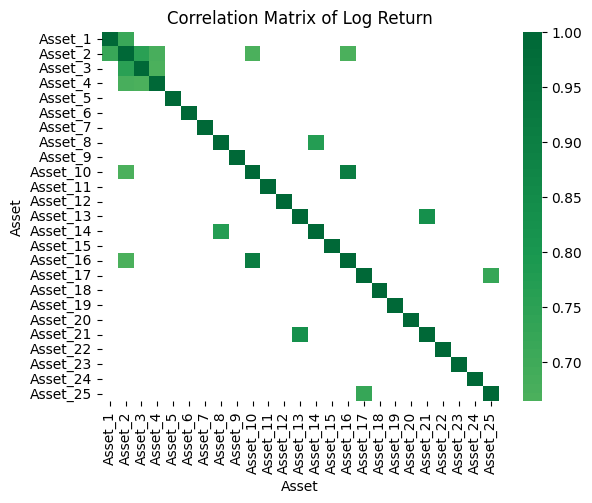

In [15]:
# For return too
thresh = 0.66
ret = df.xs("Log Return", axis=1, level="Metric")
ret = ret[1:]
ret = ret[sorted(ret.columns, key=lambda a: int(str(a).split("_")[1]))]
ret_corr = ret.corr()
ret_corr = ret_corr[ret_corr > thresh]
sns.heatmap(ret_corr, annot=False, center = 0, cmap='RdYlGn')
plt.title("Correlation Matrix of Log Return")
plt.show()

In [16]:
# Let's check negative correlations in returns too
ret_corr = ret_corr[ret_corr < 0]
# sns.heatmap(ret_corr, annot=False, center = 0)
# plt.title("Correlation Matrix of Log Return")
# plt.show()

ret_corr.head()


Asset,Asset_1,Asset_2,Asset_3,Asset_4,Asset_5,Asset_6,Asset_7,Asset_8,Asset_9,Asset_10,...,Asset_16,Asset_17,Asset_18,Asset_19,Asset_20,Asset_21,Asset_22,Asset_23,Asset_24,Asset_25
Asset,,,,,,,,,,,,,,,,,,,,,
Asset_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Asset_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Asset_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Asset_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Asset_5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


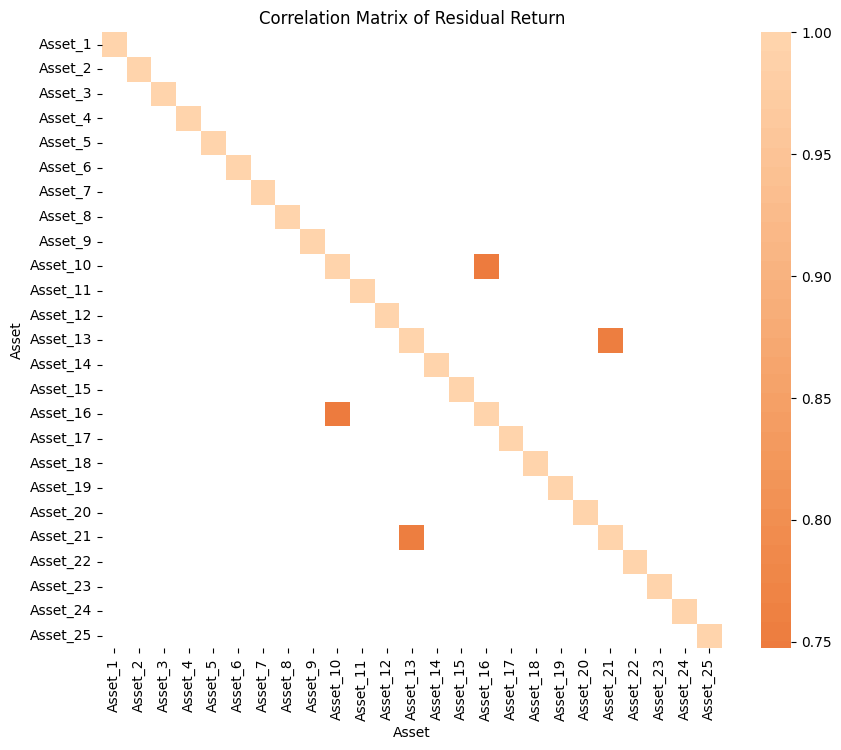

In [17]:
# That is weird, the market has no negative correlatin in returns amognst stocks.
# Let's correct for the strong market trend and check again
avg_return = ret.mean(axis=1)
resid = ret.sub(avg_return, axis=0)

# Let's check the correlation matrix between residual return (extra return except for the average market)
resid_corr = resid.corr()
# or with explicit or
resid_corr = resid_corr.where(
    (resid_corr > thresh) | (resid_corr < -thresh)
)
plt.figure(figsize=(10, 8))
sns.heatmap(resid_corr, annot=False, center = 0)
plt.title("Correlation Matrix of Residual Return")
plt.show()



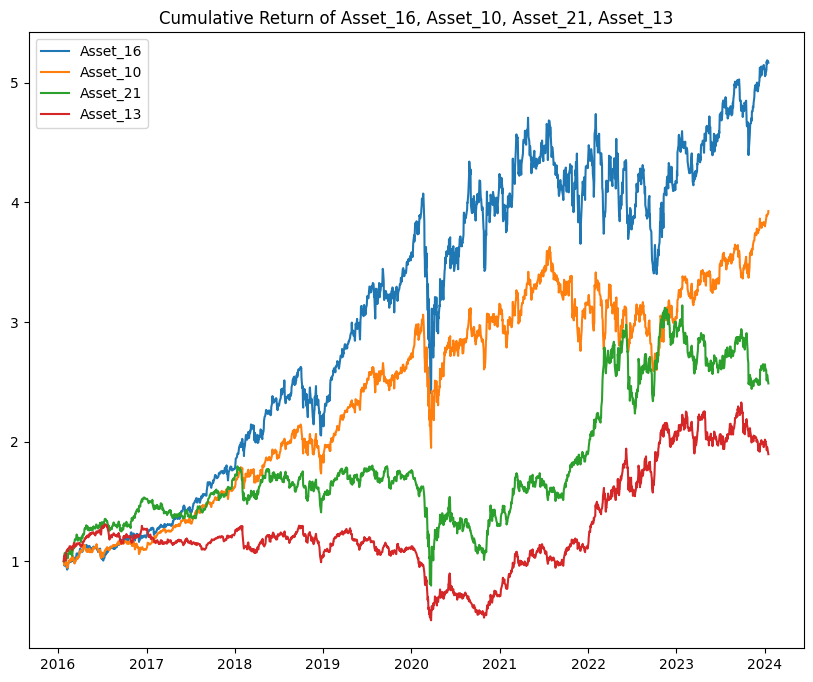

In [18]:
# Residual return between 2 pairs of assets show strong average correlation over time
# Let's check their cumulative returns

plt.figure(figsize=(10, 8))
plt.plot(df["Asset_16", "Cumulative Return"], label="Asset_16")
plt.plot(df["Asset_10", "Cumulative Return"], label="Asset_10")
plt.plot(df["Asset_21", "Cumulative Return"], label="Asset_21")
plt.plot(df["Asset_13", "Cumulative Return"], label="Asset_13")
plt.title("Cumulative Return of Asset_16, Asset_10, Asset_21, Asset_13")
plt.legend()
plt.show()


These four names are not one pattern. Residual returns pick out two clusters (16 with 10, 21 with 13). Cumulative prices show the same: two pairs that track internally, and only share the market trend with each other.

In [19]:
df.head()

Asset         Asset_1                                                     \
Metric          Close Cumulative Return       High Log Return        Low   
Date                                                                       
2016-01-25  28.580592          1.000000  29.181290        NaN  28.514486   
2016-01-26  28.738659          1.005531  28.994458   0.005515  28.186822   
2016-01-27  26.850345          0.939461  27.772948  -0.067965  26.827351   
2016-01-28  27.042913          0.946198  27.166502   0.007146  26.554308   
2016-01-29  27.977016          0.978882  27.977016   0.033958  27.117645   

Asset                                                         Asset_10  ...  \
Metric           Open Residual Return Volatility     Volume      Close  ...   
Date                                                                    ...   
2016-01-25  29.178415             NaN        NaN  249449990  42.825875  ...   
2016-01-26  28.721415       -0.003175        NaN  361581962  42.909438  ...   
2016-01-27  27.603374       -0.053738   0.005531  642328247  42.330410  ...   
2016-01-28  26.956690       -0.004237   0.016964  268157355  41.387201  ...   
2016-01-29  27.244108        0.008891   0.016541  310239413  44.467507  ...   

Asset       Asset_8    Asset_9                                          \
Metric       Volume      Close Cumulative Return       High Log Return   
Date                                                                     
2016-01-25  6633110  59.433653          1.000000  60.517437        NaN   
2016-01-26  4666986  59.615496          1.003060  59.768244   0.003055   
2016-01-27  4979853  59.470021          1.000612  60.553806  -0.002443   
2016-01-28  4437609  55.869516          0.940032  60.000995  -0.062453   
2016-01-29  8240138  57.535198          0.968058  57.767957   0.029378   

Asset                                                                  
Metric            Low       Open Residual Return Volatility    Volume  
Date                                                                   
2016-01-25  59.368192  60.008278             NaN        NaN   2767392  
2016-01-26  58.851758  59.462749       -0.005635        NaN   4817710  
2016-01-27  58.888121  59.360914        0.011783   0.003060   4563864  
2016-01-28  55.673128  59.550027       -0.073837   0.003026  10646494  
2016-01-29  56.175014  56.269571        0.004311   0.015117   7402523  

[5 rows x 225 columns]

In [20]:
# More features to look at:
## ADX
## RSI
## MACD
## Trade Volume
## CCI

# pip install pandas-ta
import pandas_ta as ta
ta_adx = ta.adx(high=df['Asset_1','High'], low=df['Asset_1','Low'], close=df['Asset_1','Close'], length=14)
ta_adx.iloc[14:34]

,ADX_14,ADXR_14_2,DMP_14,DMN_14
Date,,,,
2016-02-12,59.798294,NaN,8.017684,31.869599
2016-02-16,58.145904,58.972099,13.647998,29.449697
2016-02-17,55.803691,57.800992,16.560988,27.811625
2016-02-18,53.246791,55.696348,17.142600,25.717702
2016-02-19,50.982325,53.393008,16.678939,25.839152
2016-02-22,48.793726,51.020259,16.609846,25.093017
2016-02-23,47.298593,49.140459,15.466341,27.413447
2016-02-24,46.341242,47.567484,14.094011,28.547712
2016-02-25,45.193316,46.245955,14.592631,27.262208


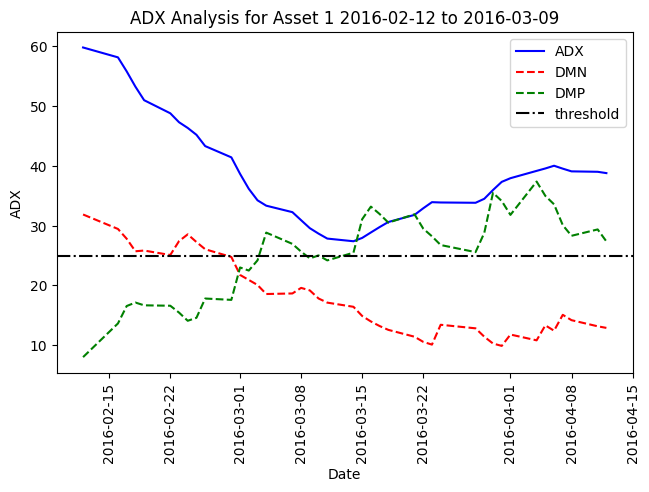

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

In [21]:
# Asset 1 trend analysis using ADX

plt.plot(ta_adx.iloc[14:55]["ADX_14"], label = "ADX", color = 'blue')
plt.plot(ta_adx.iloc[14:55]["DMN_14"], label = "DMN", color = 'red', linestyle = '--')
plt.plot(ta_adx.iloc[14:55]["DMP_14"], label = "DMP", color = 'green', linestyle = '--')
plt.xlabel('Date')
ax = plt.gca()
ax.set_xticks(ax.get_xticks()[::1])
plt.xticks(rotation=90)
plt.tight_layout()
plt.ylabel('ADX')
plt.title('ADX Analysis for Asset 1 2016-02-12 to 2016-03-09')
plt.axhline(y=25, color='black', label = 'threshold', linestyle='-.')
plt.legend()
plt.show()
plt.figure(figsize=(10, 8))


Asset 1 was experiencing Downtrend.
DMN > DMP & ADX_14 > 25 

We can use this data for a similar trend analysis

Source: https://www.investopedia.com/articles/trading/07/adx-trend-indicator.asp

In [22]:
# Similar trend analysis over other metrics

h = df["Asset_1", "High"]
l = df["Asset_1", "Low"]
c = df["Asset_1", "Close"]
v = df["Asset_1", "Volume"]

ta_rsi  = ta.rsi(close=c, length=14)                         # RSI_14
ta_cci  = ta.cci(high=h, low=l, close=c, length=14)          # CCI_14
ta_macd = ta.macd(close=c, fast=12, slow=26, signal=9)       # MACD, histogram, signal
ta_vol  = v / v.shift(1).rolling(20).median()                # today's vol / prior 20-day median

In [23]:
ta_macd.iloc[27:55]

,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9
Date,,,
2016-03-03,0.395789,NaN,NaN
2016-03-04,0.479915,NaN,NaN
2016-03-07,0.514076,NaN,NaN
2016-03-08,0.515619,NaN,NaN
2016-03-09,0.513026,NaN,NaN
2016-03-10,0.506301,NaN,NaN
2016-03-11,0.520389,0.072732,0.447656
2016-03-14,0.531490,0.067067,0.464423
2016-03-15,0.581617,0.093756,0.487862


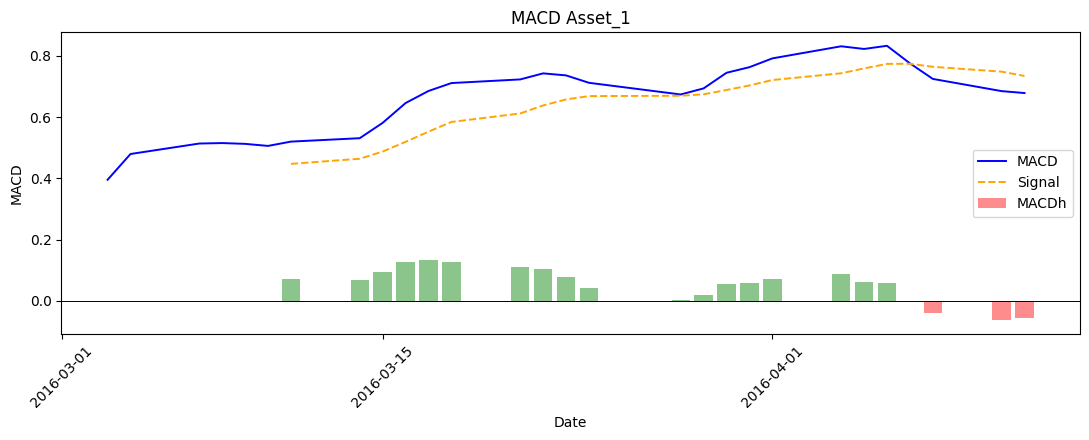

In [24]:
# MACD Analysis Histogram

macd = ta_macd.iloc[27:55]
hist = macd["MACDh_12_26_9"]
colors = np.where(hist >= 0, "green", "red")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(macd.index, hist, color=colors, width=0.8, alpha=0.45, label="MACDh")
ax.plot(macd.index, macd["MACD_12_26_9"], color="blue", lw=1.4, label="MACD")
ax.plot(macd.index, macd["MACDs_12_26_9"], color="orange", lw=1.4, ls="--", label="Signal")
ax.axhline(0, color="k", lw=0.7)

ax.set_title("MACD Asset_1")
ax.set_xlabel("Date")
ax.set_ylabel("MACD")
ax.legend()
ax.set_xticks(ax.get_xticks()[::2])
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

Asset 1 has >0 histogram initially => bullish 
But the market turns bearish later

Around 8th March, ADX starts uptrend
At 11 March, MACDh > 0, MACD > MACDs so the uptrend still exists
For more information about the MACD, source : https://www.investopedia.com/terms/m/macd.asp

If we check the price of stock around this period: 

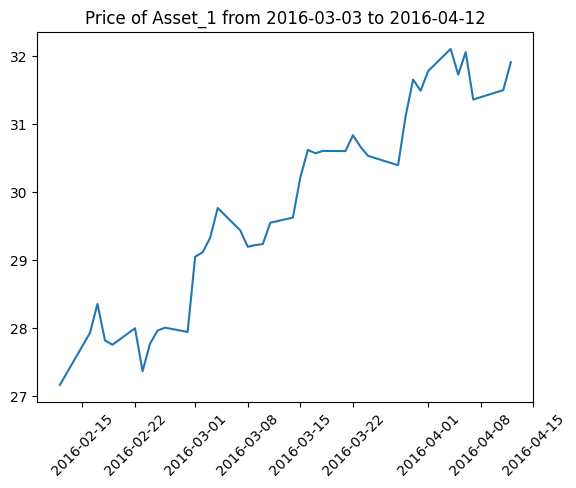

In [25]:
# Price of stock during this period
plt.plot(df["Asset_1", "Close"][14:55])
plt.title("Price of Asset_1 from 2016-03-03 to 2016-04-12")
ax.set_xticks(ax.get_xticks()[::2])
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

We find an uptrend in the price of stock

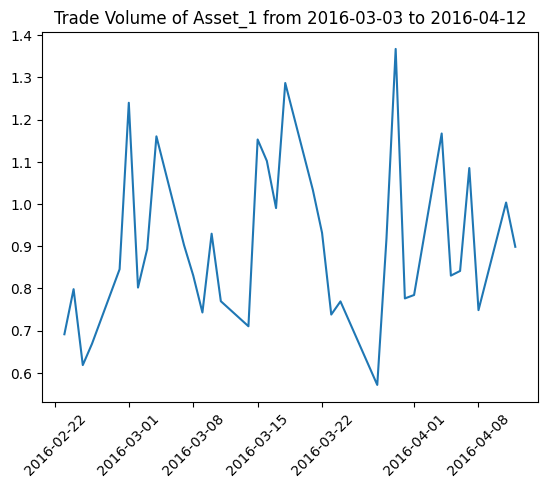

In [26]:
# Let's check the trend of volume
plt.plot(ta_vol.iloc[14:55])
plt.title("Trade Volume of Asset_1 from 2016-03-03 to 2016-04-12")
ax.set_xticks(ax.get_xticks()[::2])
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()


Raw Volume is a bad feature by itself. Asset_1’s typical size is not Asset_50’s, and volume drifts over years.

Here, we see around early April, the stock vol has has started to cool off (~ 0.9)
Around mid march, the uptrend is strong, and we can see TV reaches ~1.3 around that time, signalling high volume.

source : https://www.investopedia.com/terms/v/volumeoftrade.asp

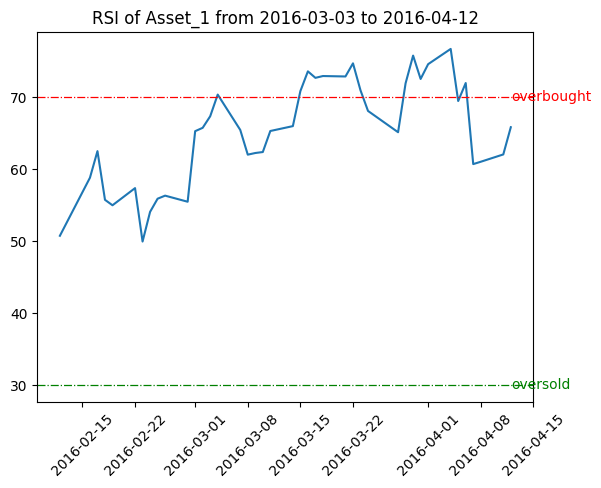

In [27]:
# Analysis of RSI
rsi = ta_rsi.iloc[14:55]
plt.plot(rsi)
plt.title("RSI of Asset_1 from 2016-03-03 to 2016-04-12")
ax.set_xticks(ax.get_xticks()[::2])
plt.xticks(rotation=45)
plt.axhline(70, color="red", ls="-.", lw=0.9)
plt.text(rsi.index[-1], 70, "overbought", color="red", va="center")
plt.axhline(30, color="green", ls="-.", lw=0.9)
plt.text(rsi.index[-1], 30, "oversold", color="green", va="center")
fig.tight_layout()
plt.show()

RSI of an asset indicates how overbought or oversold the stock is
RSI > 70 => overbought
RSI < 30 => oversold


An overbought reading during a downtrend is also much lower than 70.
High RSI signals an upcoming drop in prices but sometimes, it the prices sustain because of momentum.
Thus, another momentum indicator like MACD can provide us with more holistic picture.
Meaning we need to use this indicator with another trend indicator carefully to judge if the price of stock is going to increase or decrease.
Based on that we can assign portfolio weights to buy/hold/sell to maximise arbitrage.

source : https://www.investopedia.com/terms/r/rsi.asp

In [28]:
ta_cci.iloc[14:55]

Date
2016-02-12   -6304.860371
2016-02-16   -8318.235163
2016-02-17   -7147.685059
2016-02-18   -6986.684558
2016-02-19   -6758.694333
2016-02-22   -6266.492676
2016-02-23   -6602.298163
2016-02-24   -6613.767442
2016-02-25   -6679.545719
2016-02-26   -6198.145139
2016-02-29   -6176.484862
2016-03-01   -5506.146459
2016-03-02   -4713.911941
2016-03-03   -4325.706428
2016-03-04   -3492.920481
2016-03-07   -3024.521493
2016-03-08   -2776.442115
2016-03-09   -2682.284979
2016-03-10   -2751.014577
2016-03-11   -2855.734880
2016-03-14   -3229.215364
2016-03-15   -3736.891940
2016-03-16   -4093.267177
2016-03-17   -4053.178543
2016-03-18   -3991.316580
2016-03-21   -3655.161179
2016-03-22   -3443.783143
2016-03-23   -3364.995702
2016-03-24   -3333.785195
2016-03-28   -3546.648340
2016-03-29   -3982.395684
2016-03-30   -4459.225055
2016-03-31   -5156.974920
2016-04-01   -5192.587408
2016-04-04   -4360.539518
2016-04-05   -4007.718286
2016-04-06   -3731.958742
2016-04-07   -3840.690889
2016-04

Based on the use of cursor agent to debug what I am doing wrong to get such highly negative values, I found out a bug 
in the pandas_ta library, which is widely used to do technical analysis from OLHCV data.
In `pandas_ta/momentum/cci.py` the formula is missing parentheses:
```
# what pandas_ta does (WRONG — due to operator precedence)
cci = typical_price - mean_typical_price / (c * mad_typical_price)
# correct CCI
cci = (typical_price - mean_typical_price) / (c * mad_typical_price)
```[python]


In [ ]:
# Fixing the bug

tp = (h + l + c) / 3
mad = (tp - tp.rolling(14).mean()).abs().rolling(14).mean()
sma = tp.rolling(14).mean()
cci = (tp - sma) / (0.015 * mad)

Let's check CCI again

In [30]:
cci = cci.dropna()
cci.head()

Date
2016-03-02    166.248866
2016-03-03    159.965916
2016-03-04    167.098428
2016-03-07    114.911374
2016-03-08     81.028704
dtype: float64

updating CCI for analysis

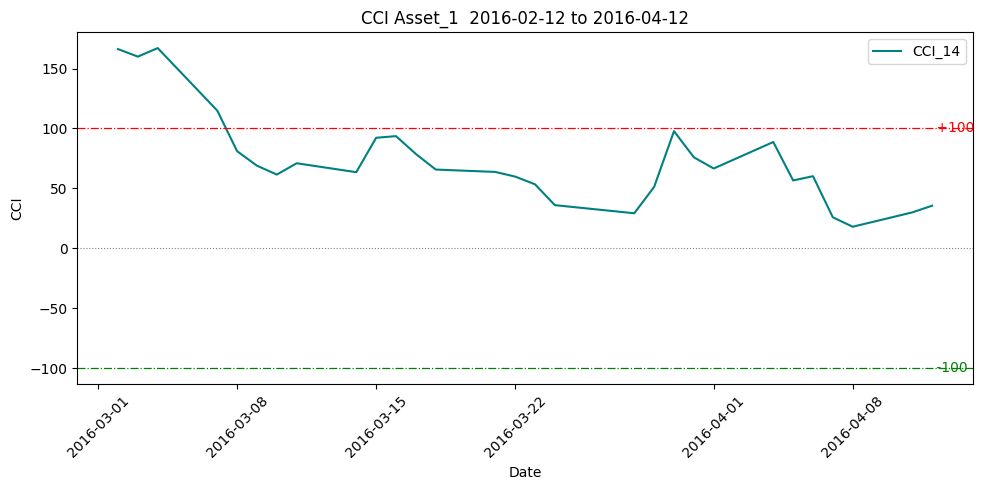

In [31]:
### CCI Analysis

cci_plot = cci.loc["2016-02-12":"2016-04-12"]   # by date, safer after dropna

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cci_plot, color="teal", label="CCI_14")
ax.axhline(100, color="red", ls="-.", lw=0.9)
ax.axhline(-100, color="green", ls="-.", lw=0.9)
ax.axhline(0, color="gray", ls=":", lw=0.8)

# label at the END OF THE PLOTTED WINDOW
ax.text(cci_plot.index[-1], 100, " +100", color="red", va="center")
ax.text(cci_plot.index[-1], -100, " -100", color="green", va="center")

ax.set_title("CCI Asset_1  2016-02-12 to 2016-04-12")
ax.set_xlabel("Date")
ax.set_ylabel("CCI")
ax.tick_params(axis="x", rotation=45)
ax.legend()
fig.tight_layout()
plt.show()

This is better, now we are getting accurate readings from cci indicator.
if CCI > 100 => beginning of solid uptrend
if CCI < 100 => beginning of solid downtrend
Here, we can see that between 8/3/2016 and 15/3/2016 - CCI was under 100, so was the asset's trade volume.
RSI here was <70 signalling that it wasn't overbought or oversold in the market,
and even the ADX touches around 30, although the DMP is above DMN, signalling a very weak uptrend in the market. 

The MACD line also signals around late 8-15 period as MACD > Signal and hist > 0 => bullish uptrend.
but smaller trade volume signals lower liquidity and stock movement. 

All of this signals that stock closing price will keep rising, but with smaller delta.
This could be interpreted as a holding period/buying period 

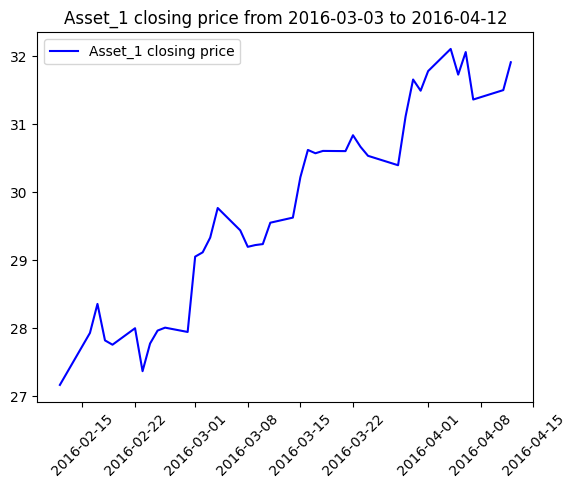

In [32]:
## Asset 1 closing price analysis 
plt.plot(c.iloc[14:55], label = "Asset_1 closing price", color = 'blue')
plt.title("Asset_1 closing price from 2016-03-03 to 2016-04-12")
ax.set_xticks(ax.get_xticks()[::2])
plt.xticks(rotation=45)
plt.legend()
plt.show()

Here, testing our basic hypothesis, we can see that betweeen the period of 8-15th March the stock did move up in price<br>
but the week before that, the stock had a massive stock uptrend, and as the ADX suggest, the uptrend in the following week was much fainter. <br>

Thus, if we would have hold the stock, or bought in this period, it would have resulted in some profit.

## PCA of the indicators

Let's check the average correlation between each is

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# build features (same dates, no NaNs)
feat = pd.DataFrame({
    "rsi": ta_rsi,
    "cci": cci,                                    # your fixed CCI, not ta_cci
    "adx": ta_adx["ADX_14"],
    "di_spread": ta_adx["DMP_14"] - ta_adx["DMN_14"],
    "macdh": ta_macd["MACDh_12_26_9"],              # one MACD column is enough
    "rel_vol": ta_vol,
}).dropna()




X = StandardScaler().fit_transform(feat)
pca = PCA()
Z = pca.fit_transform(X)

# variance explained
evr = pd.Series(
    pca.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(pca.n_components_)],
)
print(evr.round(3))
print("cumulative:\n", evr.cumsum().round(3))

# loadings: |value| large => that indicator drives that PC
loadings = pd.DataFrame(
    pca.components_.T,
    index=feat.columns,
    columns=evr.index,
)
print(loadings.round(2))

PC1    0.531
PC2    0.189
PC3    0.162
PC4    0.078
PC5    0.034
PC6    0.007
dtype: float64
cumulative:
 PC1    0.531
PC2    0.720
PC3    0.882
PC4    0.959
PC5    0.993
PC6    1.000
dtype: float64
            PC1   PC2   PC3   PC4   PC5   PC6
rsi        0.53  0.13 -0.00 -0.30 -0.27  0.73
cci        0.50 -0.19  0.12 -0.08  0.83 -0.06
adx        0.18  0.77 -0.33  0.49  0.16 -0.01
di_spread  0.52  0.16  0.01 -0.33 -0.36 -0.68
macdh      0.39 -0.44  0.14  0.74 -0.29 -0.01
rel_vol   -0.07  0.36  0.93  0.07 -0.00  0.01


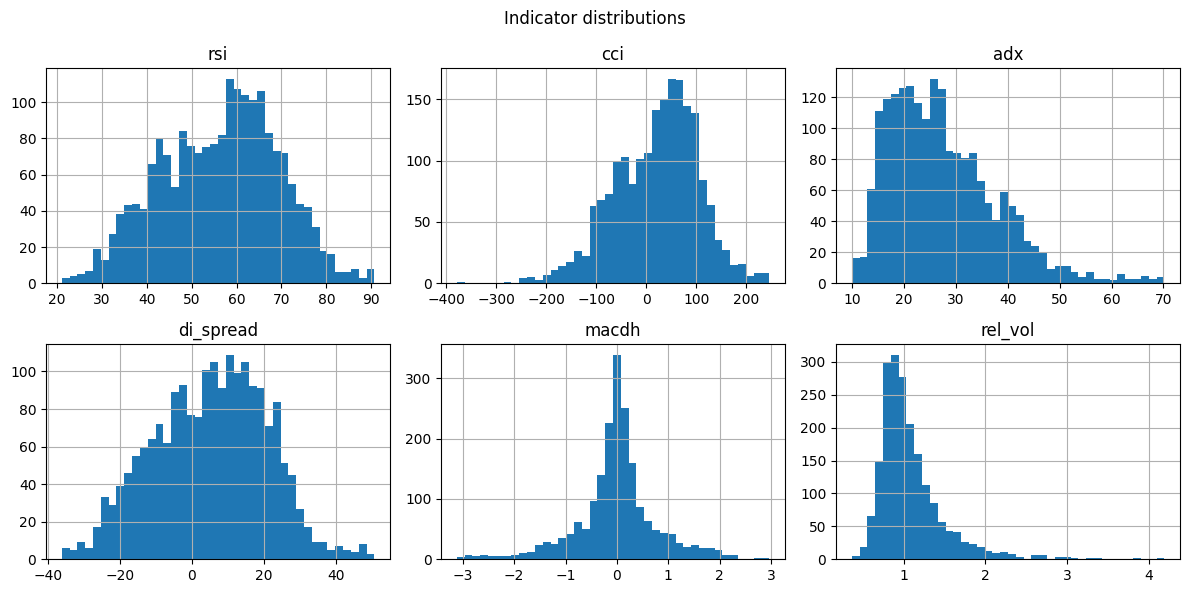

In [34]:
## EDA on indicators + PCA

pcs = pd.DataFrame(Z, index=feat.index, columns=evr.index)

# distributions
feat.hist(bins=40, figsize=(12, 6), layout=(2, 3))
plt.suptitle("Indicator distributions")
plt.tight_layout()
plt.show()

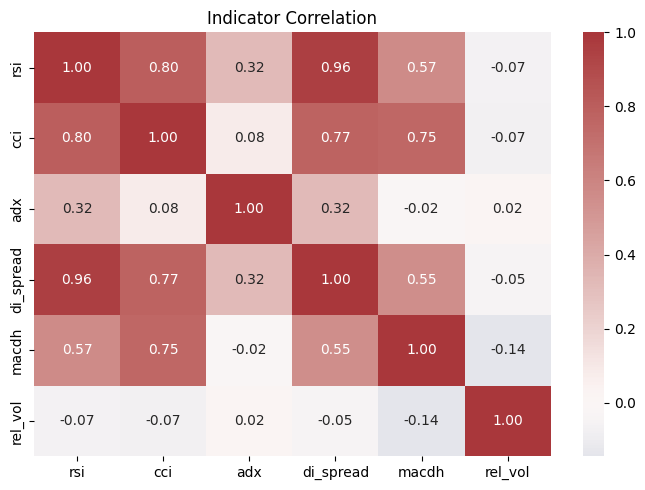

In [35]:
# Checking Correlation between indicators. 

plt.figure(figsize=(7, 5))
sns.heatmap(feat.corr(method="spearman"), cmap="vlag", center=0, annot=True, fmt=".2f") # Using Spearman instead of Pearson (non linear relationship)
plt.title("Indicator Correlation")
plt.tight_layout()
plt.show()

# Feature Selection

To rank the features on the basis of their importance in prediction.

To achieve this, I was planning to use LASSO method, but I realised the
non-linearity of data makes the linear model based LASSO inefficient.

I can use Model based approach and back it by ICIR testing

In [36]:
df = Utils.add_market_indicators(df).dropna()

List of features:

In [37]:
# df.loc[:, "Asset_1"].info()
df.shape

(1976, 450)

In [38]:
# daily cross-sectional IC, then mean / IR / yearly windows
SKIP = {"Open", "High", "Low", "Close", "Cumulative Return"}
fwd = df.xs("Log Return", axis=1, level="Metric").shift(-1)
metrics = [m for m in df.columns.get_level_values("Metric").unique() if m not in SKIP]
ic_by_feature = {}
rows = []
for metric in metrics:
    x = df.xs(metric, axis=1, level="Metric")
    ic_t = x.corrwith(fwd, axis=1, method="spearman").dropna()
    ic_by_feature[metric] = ic_t
    yearly = ic_t.groupby(ic_t.index.year).mean()
    rows.append({
        "metric": metric,
        "mean_ic": ic_t.mean(),
        "ir": ic_t.mean() / ic_t.std(),
        "hit": (ic_t > 0).mean(),
        "years_pos": int((yearly > 0).sum()),
        "n_years": int(yearly.size),
    })
ic_table = (
    pd.DataFrame(rows).set_index("metric")
    .sort_values("ir", key=lambda s: s.abs(), ascending=False)
)
yearly_ic = pd.DataFrame({m: s.groupby(s.index.year).mean() for m, s in ic_by_feature.items()})
yearly_ir = pd.DataFrame({
    m: s.groupby(s.index.year).mean() / s.groupby(s.index.year).std()
    for m, s in ic_by_feature.items()
})
yearly_ic.round(3)

,ADXR_14_2,ADX_14,CCI,DMN_14,DMP_14,Log Return,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,RSI,Residual Return,Volatility,Volume
Date,,,,,,,,,,,,,
2016,0.000,0.001,-0.022,0.033,-0.021,-0.039,-0.024,-0.008,-0.022,-0.030,-0.039,0.038,0.038
2017,-0.023,-0.020,0.009,0.008,-0.006,0.007,-0.013,-0.004,-0.007,0.003,0.007,0.029,0.011
2018,-0.005,-0.004,-0.016,-0.016,-0.022,-0.045,0.014,-0.006,0.022,-0.006,-0.045,-0.013,-0.008
2019,-0.002,0.001,-0.033,0.030,-0.013,-0.009,-0.006,-0.043,-0.001,-0.020,-0.009,0.041,0.014
2020,0.020,0.019,0.014,-0.016,0.017,-0.016,0.023,-0.023,0.034,0.022,-0.016,0.002,0.007
2021,0.004,0.004,0.016,-0.014,0.012,-0.007,0.002,0.014,-0.004,0.013,-0.007,0.005,0.008
2022,0.018,0.014,0.027,-0.020,0.011,0.011,0.012,-0.007,0.012,0.027,0.011,-0.042,-0.035
2023,-0.005,-0.003,0.019,-0.011,0.018,-0.011,-0.000,0.016,-0.010,0.015,-0.011,0.041,0.042
2024,0.008,0.007,0.113,-0.075,0.040,0.185,0.080,-0.007,0.070,0.108,0.185,0.083,-0.050


IC IR can't be valid indicators because the indicators can lag. 
I am targetting against Daily log returns here.
Instead, I can maybe get an average trend score in the next 2 weeks and IC on that

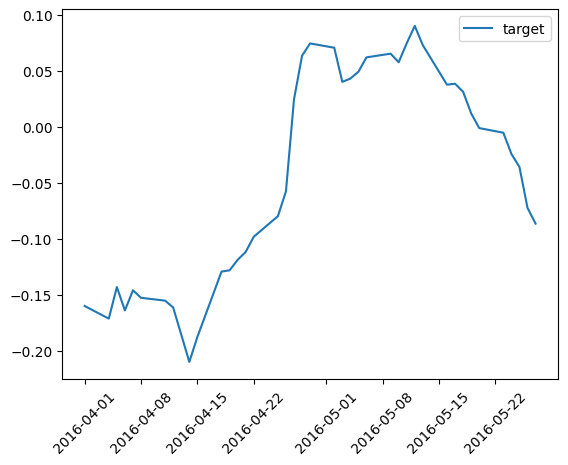

In [39]:
# for asset in df.columns.get_level_values(0).unique():
asset = "Asset_1"
adf = df.loc[:, asset].copy()
adf["target"] = adf["Log Return"].rolling(20).sum().shift(-20)
plt.plot(adf["target"][14:55], label = "target")
ax.set_xticks(ax.get_xticks()[::2])
plt.xticks(rotation=45)
plt.legend()
plt.show()

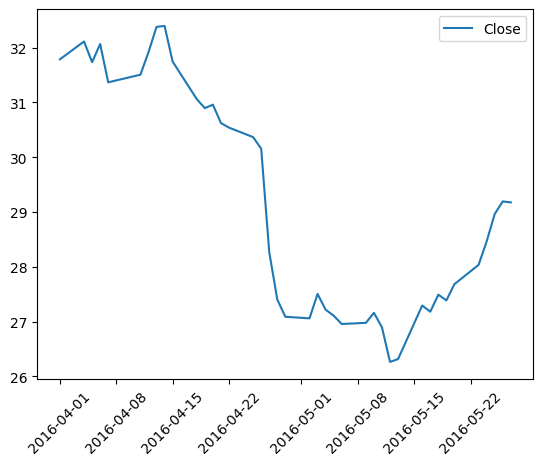

In [40]:
plt.plot(adf["Close"][14:55], label = "Close")
ax.set_xticks(ax.get_xticks()[::2])
plt.xticks(rotation=45)
plt.legend()
plt.show()

Based on this observation, the target seems inverted to the price. 
Formula here for target : 
$$ y_t = \sum_{k=1}^{20} r_{t+k} = \log\frac{P_{t+20}}{P_t} $$


This looks inverted because we are comparing today's price with price in 20 days future, which is basically derivative of the price.<br/>
What we can do instead of this is to use a model based feature selection.

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr

HORIZON = 5
SKIP = {"Open", "High", "Low", "Close", "Cumulative Return"}
df = df.loc[:, ~df.columns.duplicated()].copy()

close = df.xs("Close", axis=1, level="Metric")
y_wide = (close.shift(-HORIZON) / close - 1) / HORIZON

feat_names = [m for m in df.columns.get_level_values("Metric").unique() if m not in SKIP]
X_wide = {m: df.xs(m, axis=1, level="Metric") for m in feat_names}

panel = pd.concat(
    {m: X_wide[m].stack() for m in feat_names} | {"target": y_wide.stack()},
    axis=1,
).dropna()
panel.index.names = ["Date", "Asset"]

# --- chronological split + embargo (overlapping 20-day y leaks across the cut) ---
dates = panel.index.get_level_values("Date").unique().sort_values()
cut = dates[int(len(dates) * 0.8)]
embargo_end = cut + pd.Timedelta(days=HORIZON)   # calendar days; dates are business days, still fine

train = panel.loc[panel.index.get_level_values("Date") <= cut]
valid = panel.loc[panel.index.get_level_values("Date") > embargo_end]

X_tr, y_tr = train[feat_names], train["target"]
X_va, y_va = valid[feat_names], valid["target"]
print(f"train days={train.index.get_level_values('Date').nunique()}  "
      f"valid days={valid.index.get_level_values('Date').nunique()}")

# --- RF: shallow + large leaves so it cannot memorize noise ---
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=80,
    min_samples_split=160,
    max_features="sqrt",
    max_samples=0.7,      # bootstrap row fraction
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_tr, y_tr)

def spearman_scorer(est, X, y):
    pred = est.predict(X)
    if np.std(pred) == 0 or np.std(y) == 0:
        return 0.0
    return spearmanr(y, pred).correlation

print("train Spearman", spearman_scorer(rf, X_tr, y_tr))
print("valid Spearman", spearman_scorer(rf, X_va, y_va))

# --- permutation on VALID only (train importance overfits) ---
perm = permutation_importance(
    rf, X_va, y_va,
    n_repeats=30,
    scoring=spearman_scorer,   # rank skill, not R^2 (R^2 ≈ 0 on daily returns)
    random_state=42,
    n_jobs=-1,
)

imp = pd.DataFrame({
    "mean": perm.importances_mean,
    "std":  perm.importances_std,
    "gini": rf.feature_importances_,
}, index=feat_names)
imp["keep"] = imp["mean"] - imp["std"] > 0   # mean lift survives the shuffle noise
imp = imp.sort_values("mean", ascending=False)
imp

train days=1577  valid days=391
train Spearman 0.11534936548256364
valid Spearman 0.02142832007379433


,mean,std,gini,keep
Volume,0.012680,0.005541,0.127542,True
DMP_14,0.006354,0.003443,0.097528,True
MACDs_12_26_9,0.003851,0.003895,0.068684,False
DMN_14,0.002545,0.002862,0.039615,False
ADX_14,0.001513,0.001385,0.021531,True
Log Return,0.001286,0.002304,0.077852,False
MACD_12_26_9,0.000064,0.003331,0.078226,False
ADXR_14_2,-0.000107,0.001849,0.015704,False
Residual Return,-0.001707,0.001835,0.031500,False
Volatility,-0.002018,0.002980,0.284302,False


I can see that Volatility is interstingly not a reliable indicator for next 5 day return. I don't think this is a good test either.

Let's use some features which are average across past few days to see how they are correlating with current market

In [42]:
# pre modelling

# Checking for Stationarity using ADF test
from statsmodels.tsa.stattools import adfuller
np.random.seed(42)

data = df.xs("Close", axis=1, level="Metric")
# check for stationarity in any one asset

result = adfuller(data['Asset_1'])

/tmp/ipykernel_3118628/3964206620.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(data['Asset_1'])


In [43]:
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1] < 0.05}')
print(f'Critical Values: {result[4]}')


ADF Statistic: -0.3222838691253459
p-value: False
Critical Values: {'1%': np.float64(-3.433695885618249), '5%': np.float64(-2.8630180142924404), '10%': np.float64(-2.5675568346245505)}


In [44]:
data = df.xs("Log Return", axis=1, level="Metric")
# check for stationarity in any one asset

result = adfuller(data['Asset_1'])

/tmp/ipykernel_3118628/1830474023.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(data['Asset_1'])


In [45]:
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1] < 0.05}')
print(f'Critical Values: {result[4]}')

ADF Statistic: -13.740270138824979
p-value: True
Critical Values: {'1%': np.float64(-3.4336788532475775), '5%': np.float64(-2.8630104945933974), '10%': np.float64(-2.567552830738709)}


In [46]:
# let's try finding features according to log return, this time, we will use rolling means instead of daily indicators
import xgboost as xgb
from stockstats import wrap, set_dft_window

data = df["Asset_1"][:250]
data = wrap(data)

rsi = data['rsi']
rsi_14 = data['rsi_6']
cci = data['cci_6']
cci_14 = data['cci_14']
adx = data['adx']
log_return = data['log-ret']
pdi = data['pdi']
ndi = data['ndi']
macds = data['macds']
macdh = data['macdh']
macd = data['macd']
set_dft_window('stochrsi', 3)
stochrsi = data['stochrsi'] # fast indicator
tema = data['tema'] # fast indicators
trade_volume = (data['volume'] / data['volume'].shift(1).rolling(20).median()).rename('trade_volume')
features = pd.concat([rsi, rsi_14, cci, cci_14, adx, log_return, pdi, ndi, stochrsi, macds, macdh, macd, tema, trade_volume], axis=1).dropna()

In [47]:
data[['log-ret', 'Log Return']]

Metric,log-ret,Log Return
Date,,
2016-03-11,0.000000,0.010716
2016-03-14,0.002539,0.002539
2016-03-15,0.019894,0.019894
2016-03-16,0.013203,0.013203
2016-03-17,-0.001605,-0.001605
...,...,...
2017-03-02,-0.005955,-0.005955
2017-03-03,0.005883,0.005883
2017-03-06,-0.003153,-0.003153


the log returns here differ cause the formulation used. Stockstat uses a more robust method for calculations, where after shifting, missing values are filled with the first value in series instead of default `NaN`

For future uses, I will be using stockstats for robust feature development.

In [48]:
features.head() # Features for Asset 1

,rsi,rsi_6,cci_6,cci_14,adx,log-ret,pdi,ndi,stochrsi,macds,macdh,macd,tema,trade_volume
Date,,,,,,,,,,,,,,
2016-04-11,61.072672,53.294403,-32.216205,43.950345,49.703097,0.003308,30.748326,11.814523,100.0,0.195438,0.001750,0.197188,31.427350,1.003698
2016-04-12,65.976525,63.967094,37.069534,54.204122,47.370256,0.012941,28.062441,11.589700,100.0,0.198694,0.012903,0.211597,31.728747,0.898791
2016-04-13,70.487936,72.472550,157.991164,132.645657,48.908635,0.014384,34.152073,10.563570,100.0,0.209353,0.042322,0.251675,32.190578,1.097644
2016-04-14,70.645123,72.761867,106.345041,139.855045,50.082506,0.000535,32.665409,10.030033,100.0,0.223755,0.057269,0.281025,32.393792,0.840756
2016-04-15,58.139360,49.398258,13.684992,53.377577,43.868166,-0.020276,28.859524,16.115020,0.0,0.230098,0.025253,0.255352,32.002452,1.657456


In [53]:
features.columns

Index(['rsi', 'rsi_6', 'cci_6', 'cci_14', 'adx', 'log-ret', 'pdi', 'ndi',
       'stochrsi', 'macds', 'macdh', 'macd', 'tema', 'trade_volume'],
      dtype='str')

In [ ]:
# Now we have a lot of features, let's get signals in the next notebook